## Install Libraries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import torch
from torch.utils.data import Dataset
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


## Load Train and Test Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# DATASET_PATH = Path("/content/drive/MyDrive/Colab Notebooks/tdcsfog")
DATASET_PATH = Path("/kaggle/input/tds-fog-windowed-dataset/tdcsfog")
TRAIN_PATH = DATASET_PATH / "train"
TEST_PATH = DATASET_PATH / "test"

In [3]:
file_path = '/kaggle/input/tds-fog-windowed-dataset/tdcsfog/test/009ee11563_0000.npy'

with open(file_path, "rb") as infile:
        arr = np.load(infile)

print(arr.shape)
arr[1]
# # Extract the accelerometer data as the input features
# features = arr[:, 1:4]

# # Extract the labels
# labels = arr[:, 4:]
# labels = np.max(labels, axis=-1)
# return features, np.any(labels).astype(float)

(1280, 7)


array([ 1.        , -9.42509672,  0.7682455 , -1.75057992,  0.        ,
        0.        ,  0.        ])

In [4]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset



def load_windowed_data_with_label(folder_path, rolling_window=5):
    X = []
    y = []

    for filename in os.listdir(folder_path):
        if filename.endswith(".npy"):
            arr = np.load(os.path.join(folder_path, filename))  # shape: (window_len, 7)

            features = arr[:, 1:4]    # 3 original features (acc_x, acc_y, acc_z)
            labels = arr[:, 4:]      # last 3 columns = FoG levels

            # Convert to DataFrame for rolling
            df_feat = pd.DataFrame(features, columns=['acc_x', 'acc_y', 'acc_z'])

            # Add rolling average columns (window=5)
            for col in df_feat.columns:
                df_feat[f'{col}_avg'] = df_feat[col].rolling(window=rolling_window, min_periods=1).mean()

            features_with_avg = df_feat.to_numpy()  # shape: (1280, 6)

            # Create label: if any row in any of the 3 FoG columns has 1
            label = int(np.any(labels > 0))

            X.append(features_with_avg)
            y.append(label)

    return np.array(X), np.array(y)

In [5]:
X, y = load_windowed_data_with_label(TRAIN_PATH)



from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
X_test, y_test = load_windowed_data_with_label(TEST_PATH)

In [7]:
from torch.utils.data import TensorDataset, DataLoader

X_tensor_train = torch.tensor(X_train, dtype=torch.float32)
y_tensor_train = torch.tensor(y_train, dtype=torch.float32)

dataset_train = TensorDataset(X_tensor_train, y_tensor_train)
train_loader = DataLoader(dataset_train, batch_size=32, shuffle=False)

#--------------------------------------

X_tensor_val = torch.tensor(X_val, dtype=torch.float32)
y_tensor_val = torch.tensor(y_val, dtype=torch.float32)

dataset_val = TensorDataset(X_tensor_val, y_tensor_val)
val_loader = DataLoader(dataset_val, batch_size=32, shuffle=False)

#--------------------------------------

X_tensor_test = torch.tensor(X_test, dtype=torch.float32)
y_tensor_test = torch.tensor(y_test, dtype=torch.float32)

dataset_test = TensorDataset(X_tensor_test, y_tensor_test)
test_loader = DataLoader(dataset_test, batch_size=32, shuffle=False)


In [8]:
print(X_train.shape)
print(y_train.shape)
print('-'*20)
print(X_val.shape)
print('-'*20)
print(X_test.shape)
print('-'*20)


(3308, 1280, 6)
(3308,)
--------------------
(828, 1280, 6)
--------------------
(960, 1280, 6)
--------------------


In [9]:
print("Train label distribution:", torch.unique(y_tensor_train, return_counts=True))
print(torch.unique(y_tensor_train))  # must be tensor([0., 1.])
print(y_tensor_val.dtype)          # must be torch.float32

Train label distribution: (tensor([0., 1.]), tensor([1657, 1651]))
tensor([0., 1.])
torch.float32


## GRU Model

In [ ]:
import torch
import torch.nn as nn

class DeepGRUModel(nn.Module):
    def __init__(self, input_size=6, hidden_size=128, num_layers=3, dropout=0.3):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True  # optional but effective
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),  # *2 due to bidirectional
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)  # output raw logits
        )

    def forward(self, x):
        out, _ = self.gru(x)              # out: (B, T, 2*H)
        out = out[:, -1, :]               # last time step: (B, 2*H)
        return self.classifier(out)       # logits → use BCEWithLogitsLoss


## TFT model

In [11]:
from typing import Optional, Tuple

In [12]:
class GatedResidualNetwork(nn.Module):
    """Light‑weight GRN from the TFT paper (without context vectors)."""

    def __init__(self, in_dim: int, hidden_dim: int, out_dim: Optional[int] = None, dropout: float = 0.1):
        super().__init__()
        self.out_dim = out_dim or in_dim
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(hidden_dim, self.out_dim)
        self.dropout = nn.Dropout(dropout)
        # GLU expects 2×channels → concatenate with itself
        self.gate = nn.GLU()
        self.skip = nn.Identity() if in_dim == self.out_dim else nn.Linear(in_dim, self.out_dim)
        self.norm = nn.LayerNorm(self.out_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)
        x = self.fc1(x)
        x = self.elu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.gate(torch.cat([x, x], dim=-1))
        return self.norm(x + residual)


class TemporalFusionTransformer(nn.Module):
    """Minimal Temporal Fusion Transformer (sequence‑level binary classification)."""

    def __init__(
        self,
        input_size: int = 6,
        hidden_size: int = 64,
        lstm_layers: int = 1,
        attn_heads: int = 4,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        self.hidden_size = hidden_size

        # 1. Variable selection / embedding
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.var_gate = GatedResidualNetwork(hidden_size, hidden_size)

        # 2. Sequence encoding (bi‑LSTM)
        self.lstm = nn.LSTM(
            hidden_size,
            hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
        )
        self.bidir_compress = nn.Linear(hidden_size * 2, hidden_size)

        # 3. Temporal fusion block (multi‑head self‑attention)
        self.attn = nn.MultiheadAttention(hidden_size, num_heads=attn_heads, dropout=dropout, batch_first=True)
        self.attn_grn = GatedResidualNetwork(hidden_size, hidden_size)

        # 4. Sequence‑level output head – returns (B, 1) logits
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1),  # single logit *without* squeeze
        )

    # ---------------------------------------------------------------------
    #  Forward
    # ---------------------------------------------------------------------
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, T, F)  → logits: (B, 1)"""
        # Variable selection
        x = self.input_proj(x)
        x = self.var_gate(x)

        # Temporal encoding
        x, _ = self.lstm(x)
        x = self.bidir_compress(x)  # (B, T, H)

        # Temporal fusion via interpretable attention
        attn_out, self.last_attn_weights = self.attn(x, x, x)
        x = self.attn_grn(attn_out)

        # Final logit from last step
        logits = self.head(x[:, -1])  # (B, 1)
        return logits  # KEEP 2‑D so BCEWithLogitsLoss matches y.shape (B, 1)


Training Loop

In [13]:
def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
  # Because model output is sigmoid
    train_losses = []
    val_accuracies = []
    val_precisions = []
    val_recalls = []
    val_f1_scores = []
    val_aucs = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).unsqueeze(1)  # (B,) → (B, 1)

            pred = model(xb)
            loss = criterion(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}")

        # --------- Validation Phase ---------
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device).unsqueeze(1)

                logits = model(xb)
                probs = torch.sigmoid(logits)
                all_preds.append(probs.cpu())
                all_labels.append(yb.cpu())

        y_prob = torch.cat(all_preds)
        y_true = torch.cat(all_labels)
        y_pred = (y_prob > 0.5).float()

        acc = (y_pred == y_true).float().mean()
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        auc = roc_auc_score(y_true, y_prob)

        # Print results
        print(f"Validation Accuracy:  {acc:.4f}")
        print(f"Precision:            {prec:.4f}")
        print(f"Recall:               {rec:.4f}")
        print(f"F1 Score:             {f1:.4f}")
        print(f"ROC AUC Score:        {auc:.4f}")
        print('---'*20)
        train_losses.append(avg_loss)
        val_accuracies.append(acc)
        val_precisions.append(prec)
        val_recalls.append(rec)
        val_f1_scores.append(f1)
        val_aucs.append(auc)


In [14]:
# rnn_model = RNNModel()
# GRU_model = DeepGRUModel(input_size=6, hidden_size=128, num_layers=3)

TFTmodel = TemporalFusionTransformer(input_size=6)
train_model(TFTmodel, train_loader, val_loader)

Epoch 1, Train Loss: 0.6254
Validation Accuracy:  0.6498
Precision:            0.6066
Recall:               0.8475
F1 Score:             0.7071
ROC AUC Score:        0.7331
------------------------------------------------------------
Epoch 2, Train Loss: 0.5788
Validation Accuracy:  0.6691
Precision:            0.6299
Recall:               0.8160
F1 Score:             0.7110
ROC AUC Score:        0.7622
------------------------------------------------------------
Epoch 3, Train Loss: 0.5612
Validation Accuracy:  0.6812
Precision:            0.6582
Recall:               0.7506
F1 Score:             0.7014
ROC AUC Score:        0.7836
------------------------------------------------------------
Epoch 4, Train Loss: 0.5411
Validation Accuracy:  0.6884
Precision:            0.6454
Recall:               0.8329
F1 Score:             0.7273
ROC AUC Score:        0.8143
------------------------------------------------------------
Epoch 5, Train Loss: 0.5345
Validation Accuracy:  0.7198
Precisi

In [17]:
def evaluate_on_test(model, test_loader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device).unsqueeze(1)

            logits = model(xb)
            probs = torch.sigmoid(logits)
            all_preds.append(probs.cpu())
            all_labels.append(yb.cpu())

    # Convert tensors
    y_prob = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()
    y_pred = (y_prob > 0.5).astype(float)

    # Metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    print("Test Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_true, y_pred, zero_division=0))
    print("ROC AUC:", roc_auc_score(y_true, y_prob))
    print("Confusion Matrix:\n")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format=".2f")
    plt.grid(False)
    plt.show()


    # Optionally return if needed
    return y_true, y_pred

Test Accuracy: 0.8166666666666667
Precision: 0.7795275590551181
Recall: 0.7634961439588689
F1 Score: 0.7714285714285715
ROC AUC: 0.8951237849981316
Confusion Matrix:



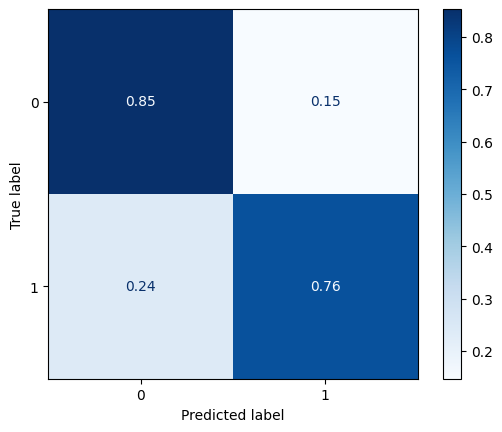

In [20]:
y_true ,y_pred =evaluate_on_test(TFTmodel, test_loader)

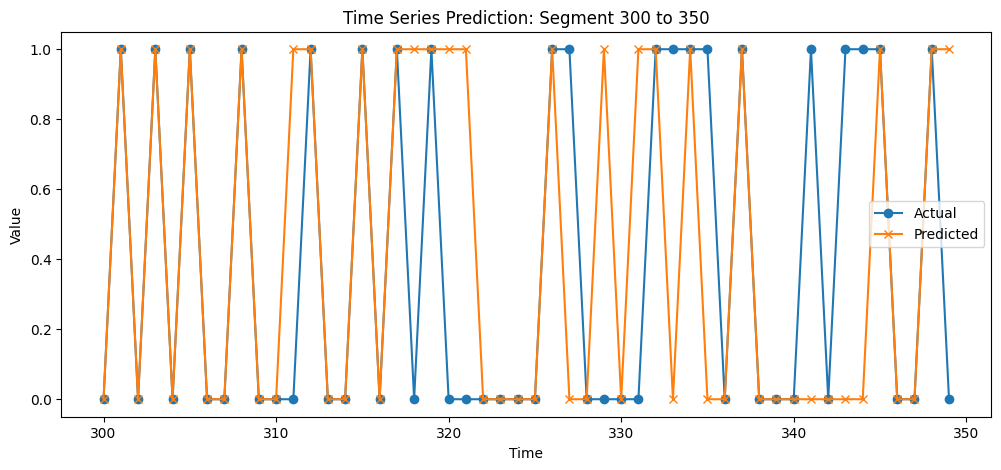

In [21]:
start = 300  # Starting index of segment
end = 350    # Ending index (exclusive)

# If y_true, y_pred are numpy arrays or lists:
time_segment = np.arange(start, end)
y_true_segment = y_true[start:end]
y_pred_segment = y_pred[start:end]

plt.figure(figsize=(12,5))
plt.plot(time_segment, y_true_segment, label='Actual', marker='o')
plt.plot(time_segment, y_pred_segment, label='Predicted', marker='x')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Time Series Prediction: Segment {start} to {end}')
plt.legend()
plt.show()